In [3]:
import pandas as pd
import numpy as np

# Visualization libraries (we'll use them later)
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
df = pd.read_csv("boston.csv")

In [6]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [7]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 506
Columns: 14


In [8]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [9]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [10]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Display only columns with missing values
missing_values[missing_values > 0]

,0


In [11]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
# Display data types
df.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,int64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,int64
TAX,float64


In [13]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", len(numerical_cols))
print("Categorical Features:", len(categorical_cols))

Numerical Features: 14
Categorical Features: 0


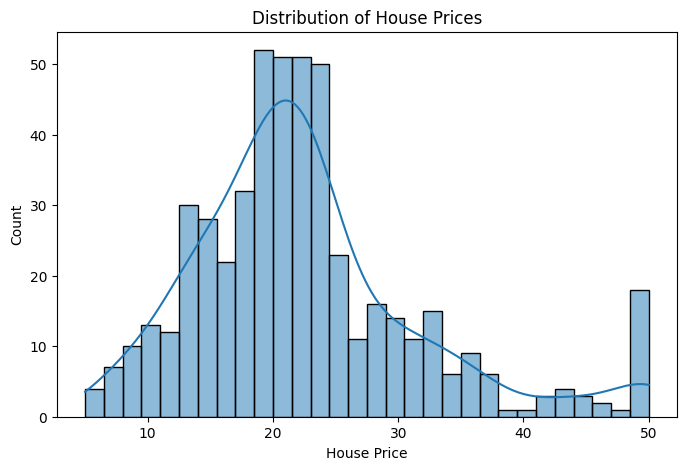

In [14]:
target = "MEDV"  # Change to "PRICE" if your dataset uses PRICE

plt.figure(figsize=(8,5))
sns.histplot(df[target], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Count")
plt.show()

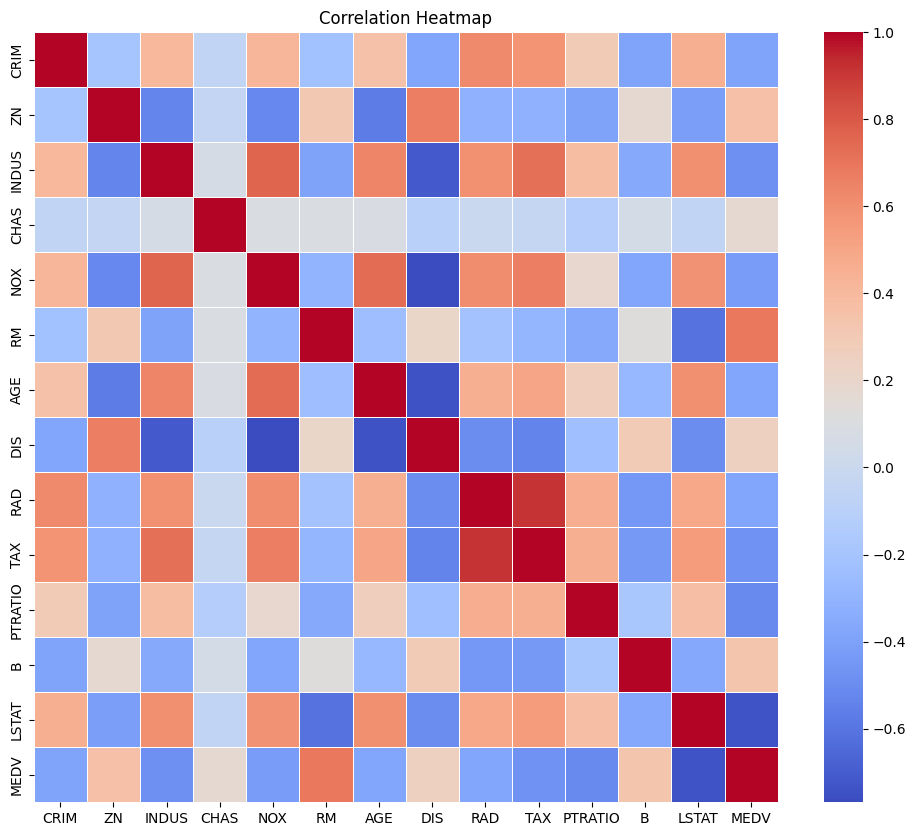

In [15]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
corr_target = (
    df.corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

print(corr_target)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


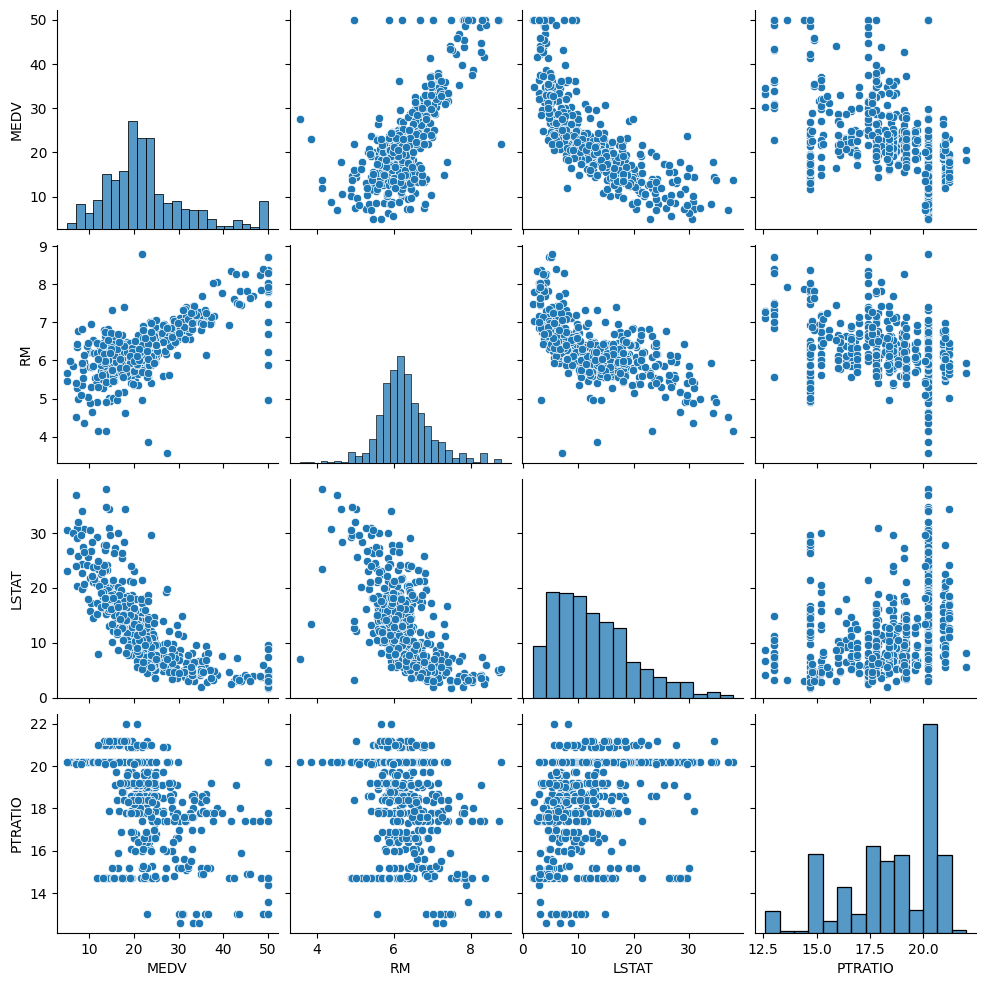

In [17]:
important_features = [
    target,
    "RM",
    "LSTAT",
    "PTRATIO"
]

sns.pairplot(df[important_features])

plt.show()

In [18]:
print(df.columns.tolist())

['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [19]:
# Replace 'MEDV' with 'PRICE' if your dataset uses PRICE
target = "MEDV"

X = df.drop(columns=[target])
y = df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (506, 13)
Target Shape: (506,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (404, 13)
Testing Set: (102, 13)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (404, 13)
Testing Set: (102, 13)


In [26]:
from sklearn.linear_model import LinearRegression

# Create the model
lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = lr.predict(X_test)

print(y_pred[:10])

[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992 23.25442929
 17.66253818 14.34119    23.01320703 20.63245597]


In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE : 3.19
MSE : 24.29
RMSE: 4.93
R² Score: 0.6688


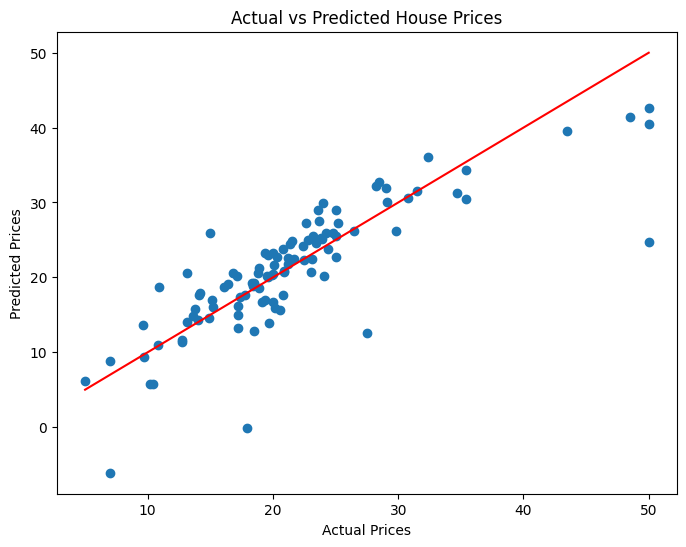

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [32]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

MAE : 2.04
RMSE: 2.92
R² Score: 0.8840


In [33]:
importance = rf.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })
    .sort_values(by="Importance", ascending=False)
)

feature_importance.head(10)

,Feature,Importance
5,RM,0.492309
12,LSTAT,0.323469
7,DIS,0.056308
0,CRIM,0.038540
4,NOX,0.015979
10,PTRATIO,0.015956
9,TAX,0.015470
6,AGE,0.015199
11,B,0.012431
2,INDUS,0.007021


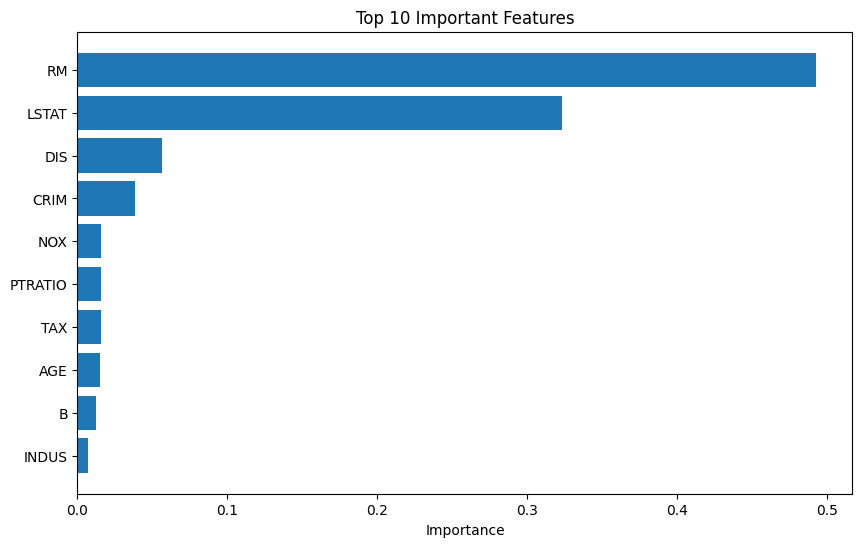

In [34]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)


Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score:
0.8260974564965702


In [38]:
import joblib

joblib.dump(grid.best_estimator_, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [39]:
from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>